In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal, optimize
from scipy.special import factorial
import re

In [91]:
def load_spectrum(path):

    text = Path(path).read_text(encoding='utf-8', errors='ignore').splitlines()
    channels = []
    counts = []

    for line in text:
        match = re.match(r'\s*(\d+),\s*(\d+)', line)
        if match:
            channels.append(float(match.group(1)))
            counts.append(float(match.group(2)))
    
    return np.array(channels), np.array(counts)

def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def poisson(x, lamb):
    return (lamb ** x) * np.exp(-lamb) / factorial(x)

def compute_chi2(o, e, dof=None):
    mask = e > 0
    chi2 = np.sum(((o[mask] - e[mask]) ** 2) / e[mask])
    if dof is not None:
        return chi2 / dof
    return chi2

def compute_stat(canais, contagens, model=None):
    c = np.array(canais)
    N = np.array(contagens)

    N_t = np.sum(N)
    if N_t == 0:
        return 0, 0, None
    
    match model:
        case 'gaussian':
            popt, _ = optimize.curve_fit(gaussian, c, N, p0=[N_t, c[np.argmax(N)], np.std(c)])
            mu = popt[1]
            sigma = popt[2]/np.sqrt(N_t)
            y_fit = gaussian(c, *popt)
            dof = len(c) - 3
            chi2 = compute_chi2(N, y_fit, dof=dof)
            return mu, sigma, chi2
        case 'poisson':
            popt, _ = optimize.curve_fit(poisson, c, N, p0=[N_t/len(canais)])
            mu = popt[0]
            sigma = np.sqrt(mu/N_t)
            y_fit = poisson(c, *popt)
            dof = len(c) - 1
            chi2 = compute_chi2(N, y_fit, dof=dof)
            return mu, sigma, chi2
        case None:
            mu = np.sum(c * N) / N_t    
            sigma = np.sqrt(np.sum((c - mu) ** 2 * N)) / N_t

            return mu, sigma, float('nan')           

    def linear(x, m, b):
        return m * x + b 

# Espetro Cs-137

In [59]:
channels_cs, counts_cs = load_spectrum('CPR1.ASC')

cs_conv_min, cs_conv_max = 100, 195
cs_beta_min, cs_beta_max = 10, 85
cs_conv_roi = slice(cs_conv_min, cs_conv_max)
cs_beta_roi = slice(cs_beta_min, cs_beta_max)
cs_conv_mu, cs_conv_sigma, cs_conv_chi2 = compute_stat(channels_cs[cs_conv_roi], counts_cs[cs_conv_roi], model=None)
cs_beta_mu, cs_beta_sigma, cs_beta_chi2 = compute_stat(channels_cs[cs_beta_roi], counts_cs[cs_beta_roi], model='gaussian')

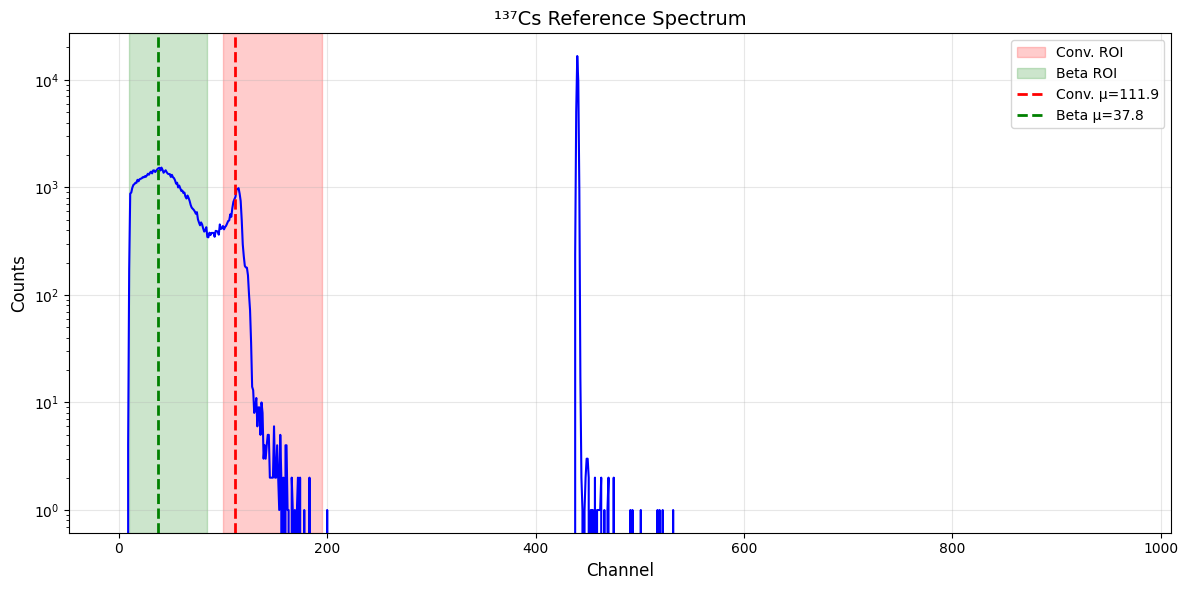

Conversão: 
  μ = 111.8793 ± 0.0600; chi² = nan
Beta: 
  μ = 37.8220 ± 0.0936; chi² = 10.2387


In [60]:


fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_cs, counts_cs, 'b-', linewidth=1.5)
ax.axvspan(cs_conv_min, cs_conv_max, alpha=0.2, color='red', label='Conv. ROI')
ax.axvspan(cs_beta_min, cs_beta_max, alpha=0.2, color='green', label='Beta ROI')
ax.axvline(cs_conv_mu, color='red', linestyle='--', linewidth=2, label=f'Conv. μ={cs_conv_mu:.1f}')
ax.axvline(cs_beta_mu, color='green', linestyle='--', linewidth=2, label=f'Beta μ={cs_beta_mu:.1f}')
ax.set_yscale('log')
ax.set_xlabel('Channel', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.set_title('¹³⁷Cs Reference Spectrum', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Conversão: \n  μ = {cs_conv_mu:.4f} ± {cs_conv_sigma:.4f}; χ² = {cs_conv_chi2:.4f}")
print(f"Beta: \n  μ = {cs_beta_mu:.4f} ± {cs_beta_sigma:.4f}; χ² = {cs_beta_chi2:.4f}")

# Pontos do Pulser

Dial 0.2

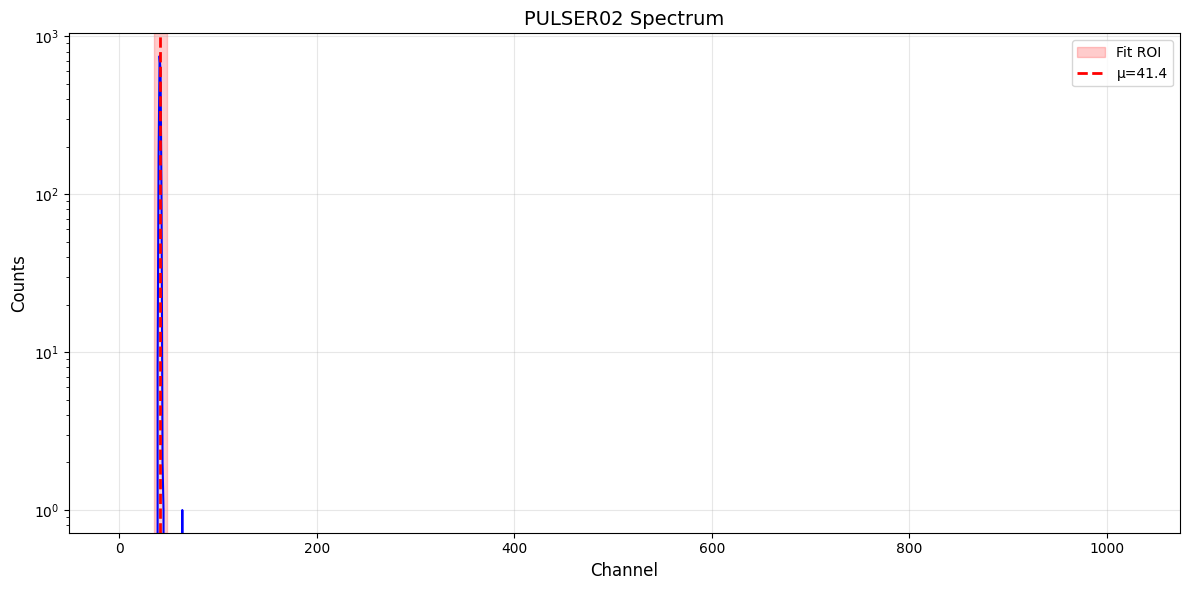

PULSER02: 
  μ = 41.3673 ± 0.0192; χ²_red = 7.3496


In [68]:
channels_02, counts_02 = load_spectrum('PULSER02.ASC')

roi01_min, roi01_max = 35, 48
roi01 = slice(roi01_min, roi01_max)
mu_02, sigma_02, chi2_02 = compute_stat(channels_02[roi01], counts_02[roi01], model='gaussian')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_02, counts_02, 'b-', linewidth=1.5)
ax.axvspan(roi01_min, roi01_max, alpha=0.2, color='red', label='Fit ROI')
ax.axvline(mu_02, color='red', linestyle='--', linewidth=2, label=f'μ={mu_02:.1f}')
ax.set_yscale('log')
ax.set_xlabel('Channel', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.set_title('PULSER02 Spectrum', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PULSER02: \n  μ = {mu_02:.4f} ± {sigma_02:.4f}; χ²_red = {chi2_02:.4f}")

Dial 0.4

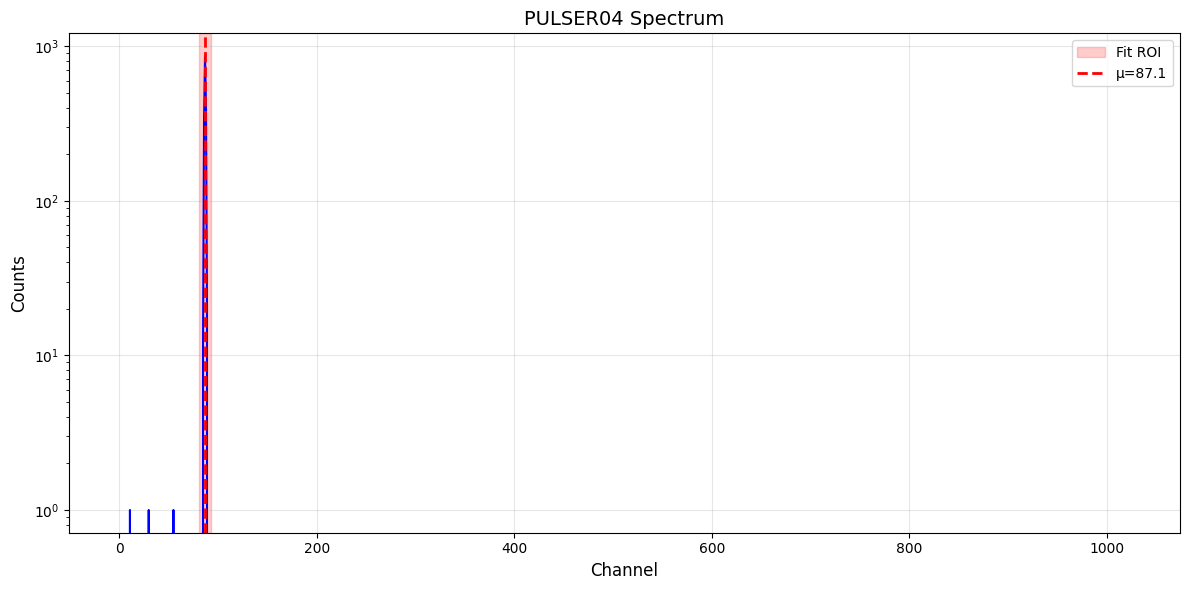

PULSER04: 
  μ = 87.0589 ± 0.0187; χ²_red = 1.0173


In [72]:
channels_04, counts_04 = load_spectrum('PULSER04.ASC')

roi02_min, roi02_max = 81, 93
roi02 = slice(roi02_min, roi02_max)
mu_04, sigma_04, chi2_04 = compute_stat(channels_04[roi02], counts_04[roi02], model='gaussian')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_04, counts_04, 'b-', linewidth=1.5)
ax.axvspan(roi02_min, roi02_max, alpha=0.2, color='red', label='Fit ROI')
ax.axvline(mu_04, color='red', linestyle='--', linewidth=2, label=f'μ={mu_04:.1f}')
ax.set_yscale('log')
ax.set_xlabel('Channel', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.set_title('PULSER04 Spectrum', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PULSER04: \n  μ = {mu_04:.4f} ± {sigma_04:.4f}; χ²_red = {chi2_04:.4f}")

Dial 0.6

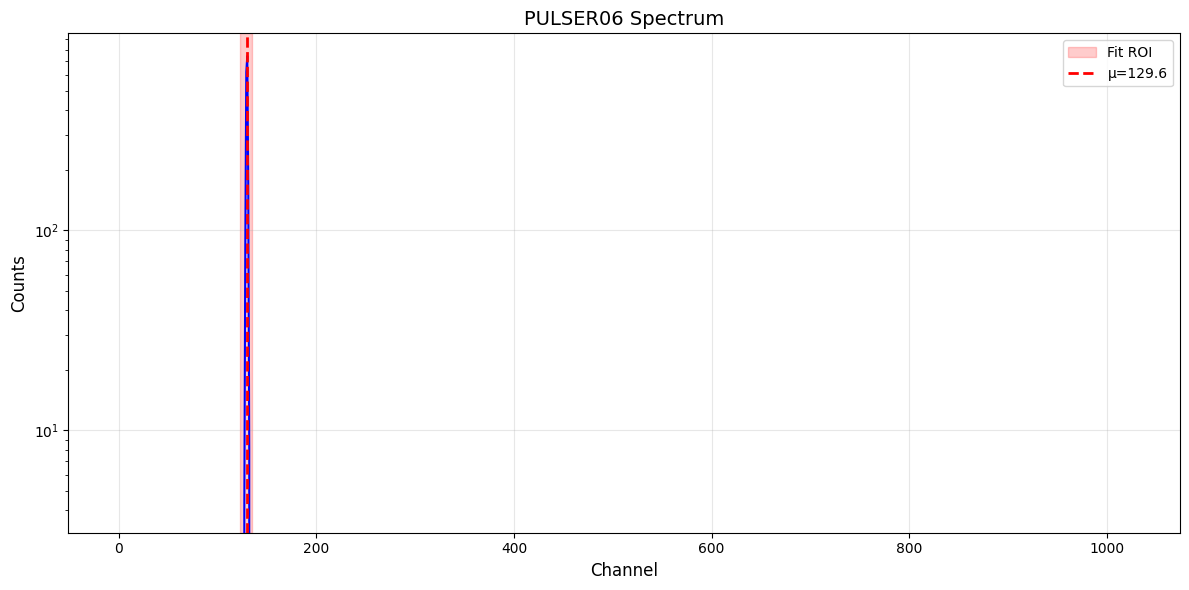

PULSER06: 
  μ = 129.6115 ± 0.0189; χ²_red = 0.2048


In [76]:
channels_06, counts_06 = load_spectrum('PULSER06.ASC')

roi03_min, roi03_max = 123, 135
roi03 = slice(roi03_min, roi03_max)
mu_06, sigma_06, chi2_06 = compute_stat(channels_06[roi03], counts_06[roi03], model='gaussian')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_06, counts_06, 'b-', linewidth=1.5)
ax.axvspan(roi03_min, roi03_max, alpha=0.2, color='red', label='Fit ROI')
ax.axvline(mu_06, color='red', linestyle='--', linewidth=2, label=f'μ={mu_06:.1f}')
ax.set_yscale('log')
ax.set_xlabel('Channel', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.set_title('PULSER06 Spectrum', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PULSER06: \n  μ = {mu_06:.4f} ± {sigma_06:.4f}; χ²_red = {chi2_06:.4f}")

Dial 0.8

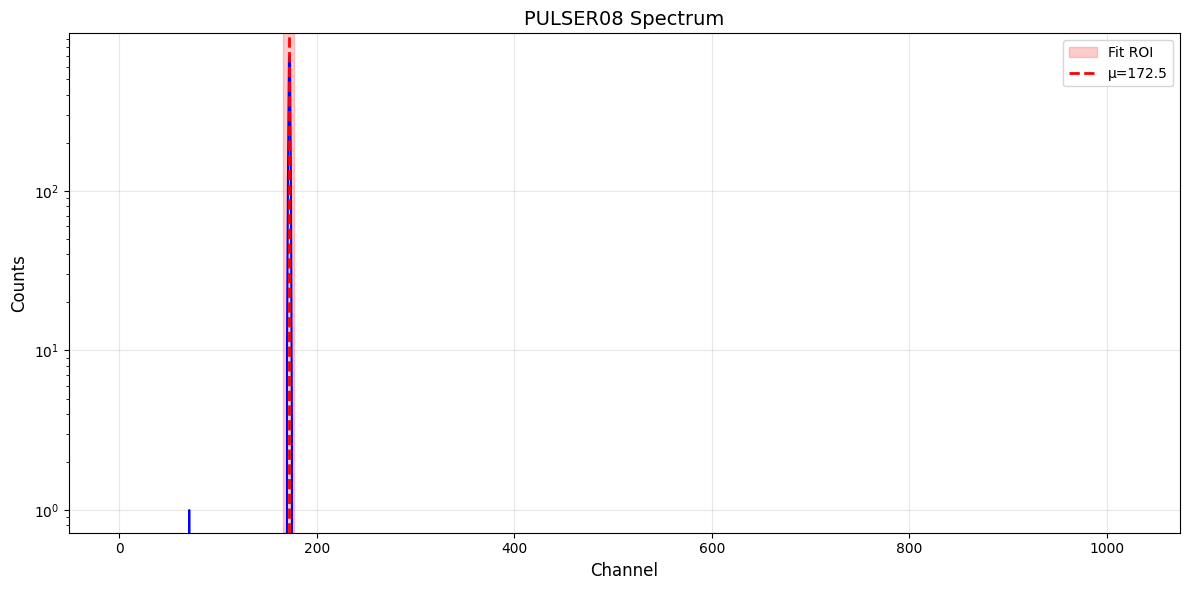

PULSER08: 
  μ = 172.5041 ± 0.0185; χ²_red = 2.2596


In [81]:
channels_08, counts_08 = load_spectrum('PULSER08.ASC')

roi04_min, roi04_max = 166, 177
roi04 = slice(roi04_min, roi04_max)
mu_08, sigma_08, chi2_08 = compute_stat(channels_08[roi04], counts_08[roi04], model='gaussian')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_08, counts_08, 'b-', linewidth=1.5)
ax.axvspan(roi04_min, roi04_max, alpha=0.2, color='red', label='Fit ROI')
ax.axvline(mu_08, color='red', linestyle='--', linewidth=2, label=f'μ={mu_08:.1f}')
ax.set_yscale('log')
ax.set_xlabel('Channel', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.set_title('PULSER08 Spectrum', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PULSER08: \n  μ = {mu_08:.4f} ± {sigma_08:.4f}; χ²_red = {chi2_08:.4f}")

Dial 1.0

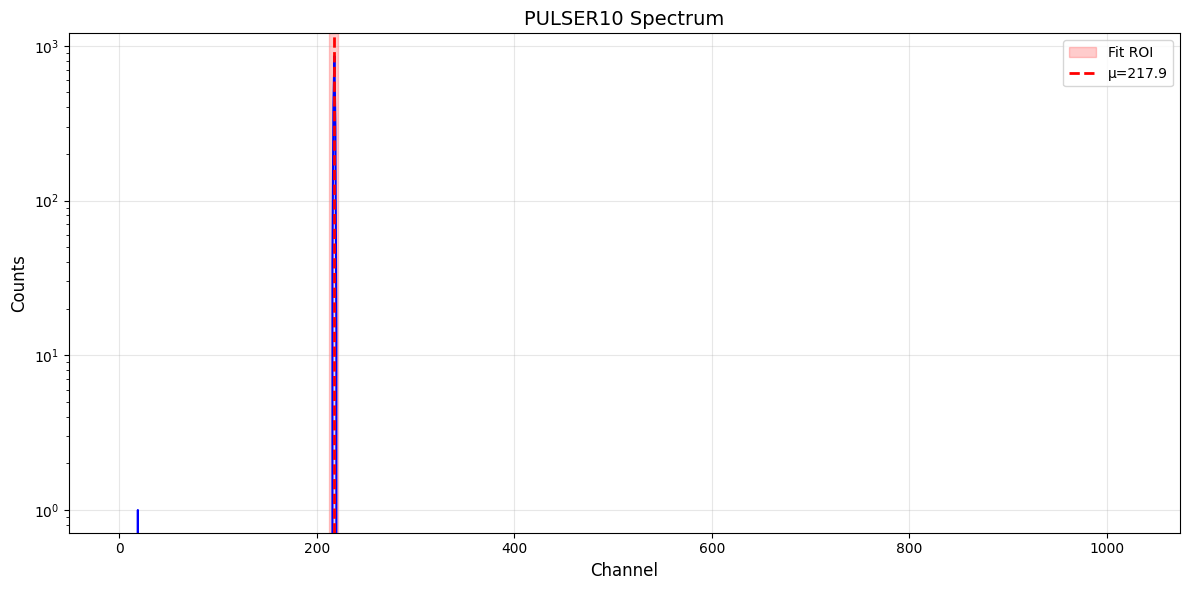

PULSER10: 
  μ = 217.9093 ± 0.0186; χ²_red = 0.3701


In [86]:
channels_10, counts_10 = load_spectrum('PULSER10.ASC')

roi05_min, roi05_max = 213, 222
roi05 = slice(roi05_min, roi05_max)
mu_10, sigma_10, chi2_10 = compute_stat(channels_10[roi05], counts_10[roi05], model='gaussian')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_10, counts_10, 'b-', linewidth=1.5)
ax.axvspan(roi05_min, roi05_max, alpha=0.2, color='red', label='Fit ROI')
ax.axvline(mu_10, color='red', linestyle='--', linewidth=2, label=f'μ={mu_10:.1f}')
ax.set_yscale('log')
ax.set_xlabel('Channel', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.set_title('PULSER10 Spectrum', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PULSER10: \n  μ = {mu_10:.4f} ± {sigma_10:.4f}; χ²_red = {chi2_10:.4f}")

Dial 1.2

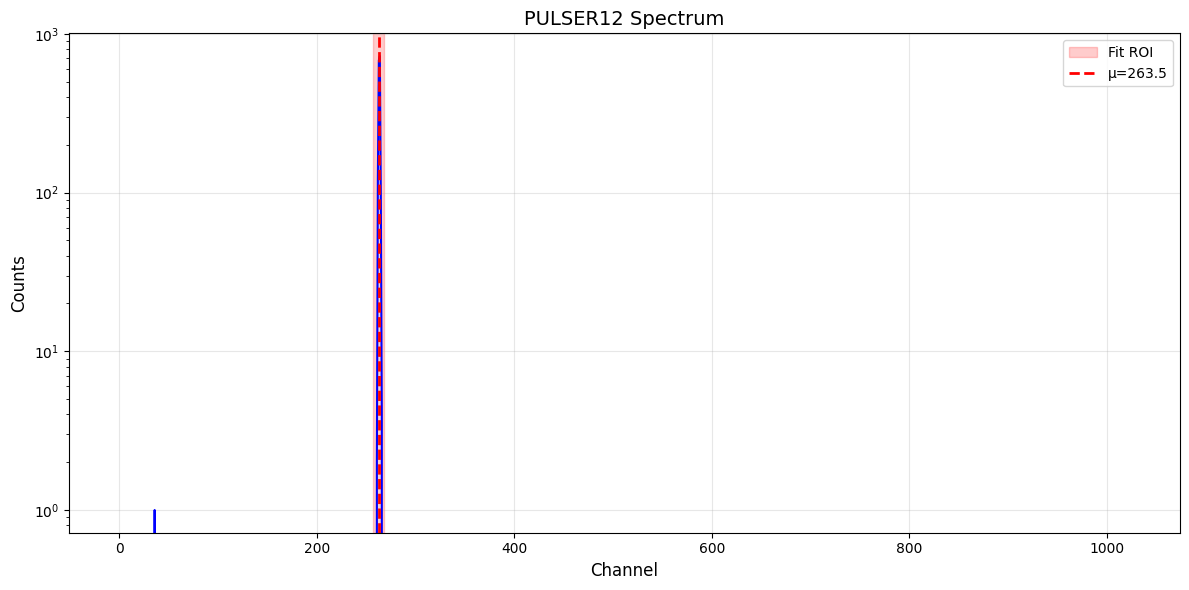

PULSER12: 
  μ = 263.5195 ± 0.0181; χ²_red = 1.0339


In [90]:
channels_12, counts_12 = load_spectrum('PULSER12.ASC')

roi06_min, roi06_max = 257, 268
roi06 = slice(roi06_min, roi06_max)
mu_12, sigma_12, chi2_12 = compute_stat(channels_12[roi06], counts_12[roi06], model='gaussian')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_12, counts_12, 'b-', linewidth=1.5)
ax.axvspan(roi06_min, roi06_max, alpha=0.2, color='red', label='Fit ROI')
ax.axvline(mu_12, color='red', linestyle='--', linewidth=2, label=f'μ={mu_12:.1f}')
ax.set_yscale('log')
ax.set_xlabel('Channel', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.set_title('PULSER12 Spectrum', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PULSER12: \n  μ = {mu_12:.4f} ± {sigma_12:.4f}; χ²_red = {chi2_12:.4f}")

# Calibração

Dials , $D$, para canais, $C$.
Reta:
$$
C = m_p D + b_p
$$

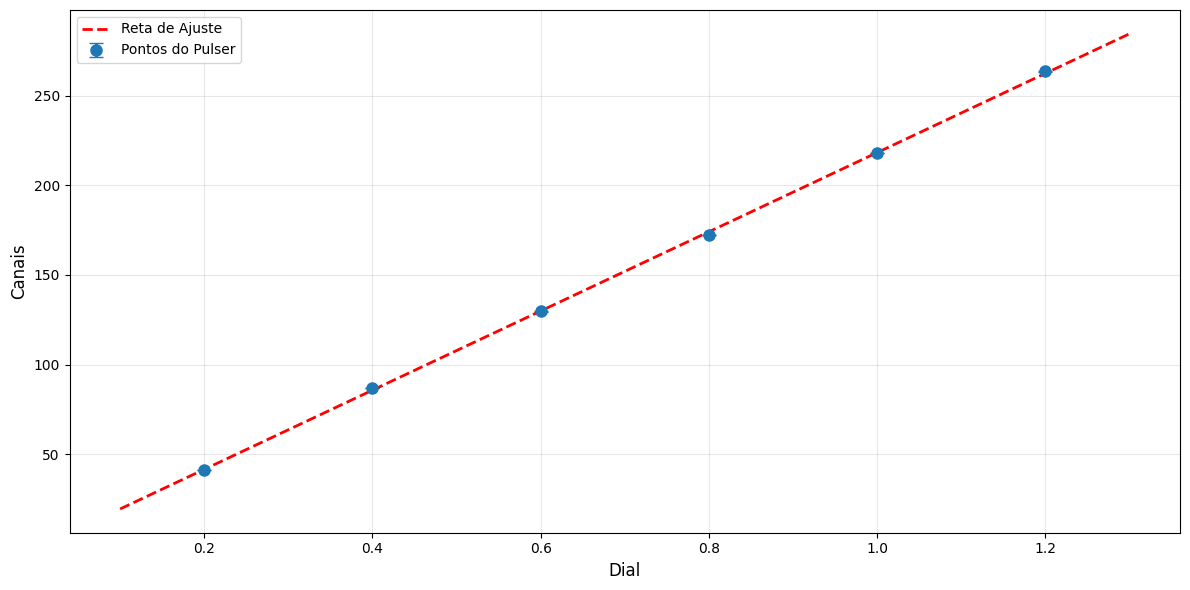

m_p = 220.924853 ± 1.435237 canais/dial
b_p = -2.65 ± 1.13 canais
χ²_red = 0.0104


In [97]:
pulser_C = np.array([mu_02, mu_04, mu_06, mu_08, mu_10, mu_12])
pulser_C_sigma = np.array([sigma_02, sigma_04, sigma_06, sigma_08, sigma_10, sigma_12])
pulser_D = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.2])

popt, pcov = optimize.curve_fit(linear, pulser_D, pulser_C, sigma=pulser_C_sigma)
perr = np.sqrt(np.diag(pcov))

pulser_C_fit = linear(pulser_D, *popt)

chi2 = compute_chi2(pulser_C, pulser_C_fit, dof=len(pulser_C) - 2)

fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(pulser_D, pulser_C, yerr=pulser_C_sigma, fmt='o', markersize=8, capsize=5, elinewidth=2, label='Pontos do Pulser')
D_plot = np.linspace(pulser_D.min() - 0.1, pulser_D.max() + 0.1, 100)
ax.plot(D_plot, linear(D_plot, *popt), 'r--', linewidth=2, label=f'Reta de Ajuste')
ax.set_xlabel('Dial', fontsize=12)
ax.set_ylabel('Canais', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"m_p = {popt[0]:.6f} ± {perr[0]:.6f} canais/dial")
print(f"b_p = {popt[1]:.2f} ± {perr[1]:.2f} canais")
print(f"χ²_red = {chi2:.4f}")

Agora traduzindo de dials para MeV, pegamos no pico de conversão do Cs-137, $C_{Cs}$,
$$D_{Cs} = \frac{C_{Cs} - b_p}{m_p}$$
Como o pulser é linear para a energia, ou seja, $D = 0 \implies E = 0\text{ MeV}$, temos a relação linear
$$ E_j = \kappa D_j $$
e podemos calcular $\kappa$, usando o pico conhecido, $\kappa = E_{Cs}/D_{Cs} $, onde $E_{Cs} = 624.215
\text{ keV}$ 

Assim, temos a nossa reta de calibração de canais para energia, $E$
$$
E = \frac{\kappa}{m_p}C - \frac{\kappa b_p}{m_p} = mC - b
$$



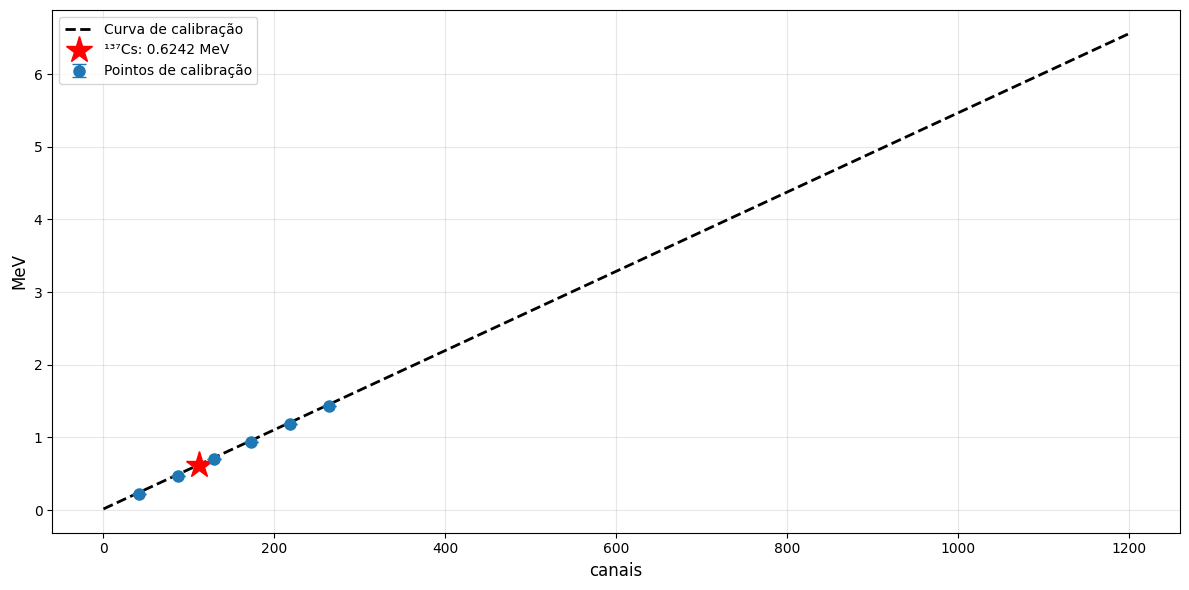

m = 0.005451 ± 0.000074 MeV/ch
b = 0.014417 ± 0.006174 MeV


In [114]:
cs_conv_ene = 0.624215 #MeV

cs_conv_dial = (cs_conv_mu - popt[1]) / popt[0]
cs_conv_dial_sigma = np.sqrt((cs_conv_sigma / popt[0]) ** 2 + ((cs_conv_mu - popt[1]) * perr[0] / popt[0] ** 2) ** 2 + (perr[1] / popt[0]) ** 2)

kappa = cs_conv_ene / cs_conv_dial
kappa_sigma = np.abs(cs_conv_ene / cs_conv_dial ** 2) * cs_conv_dial_sigma

pulser_energies = kappa * pulser_D
#A incerteza dos dials é 0.01, menor divisão da escala
pulser_energies_sigma = np.sqrt((kappa_sigma * pulser_D) ** 2 + (kappa * 0.01) ** 2)

m = kappa/ popt[0]
m_sigma = np.sqrt((perr[0] * kappa/ popt[0]**2) ** 2 + (kappa_sigma/popt[0]) ** 2)
b = -popt[1] * kappa/popt[0]
b_sigma = np.sqrt((perr[1] * kappa / popt[0]) ** 2 + (popt[1] * kappa_sigma / popt[0]) ** 2 + (popt[1] * kappa * perr[0] / popt[0] ** 2) ** 2)

channels_plot = np.linspace(0, 1200, 1000)
energy_plot = m * channels_plot + b

pulser_energies_calib = m * pulser_C

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_plot, energy_plot, 'k--', linewidth=2, label='Curva de calibração')
ax.errorbar(pulser_C, pulser_energies_calib, yerr=pulser_C_sigma * m, fmt='o', markersize=8, capsize=5, elinewidth=2, label='Pointos de calibração')
ax.plot(cs_conv_mu, cs_conv_ene, 'r*', markersize=20, label=f'¹³⁷Cs: {cs_conv_ene:.4f} MeV')
ax.set_xlabel('canais', fontsize=12)
ax.set_ylabel('MeV', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"m = {m:.6f} ± {m_sigma:.6f} MeV/ch")
print(f"b = {b:.6f} ± {b_sigma:.6f} MeV")



Calibração final:

$m = 0.005451 \pm 0.000074 \text{ MeV/ch}$

$b = 0.014417 \pm 0.006174 \text{ MeV}$

## Calibração com curve_fit

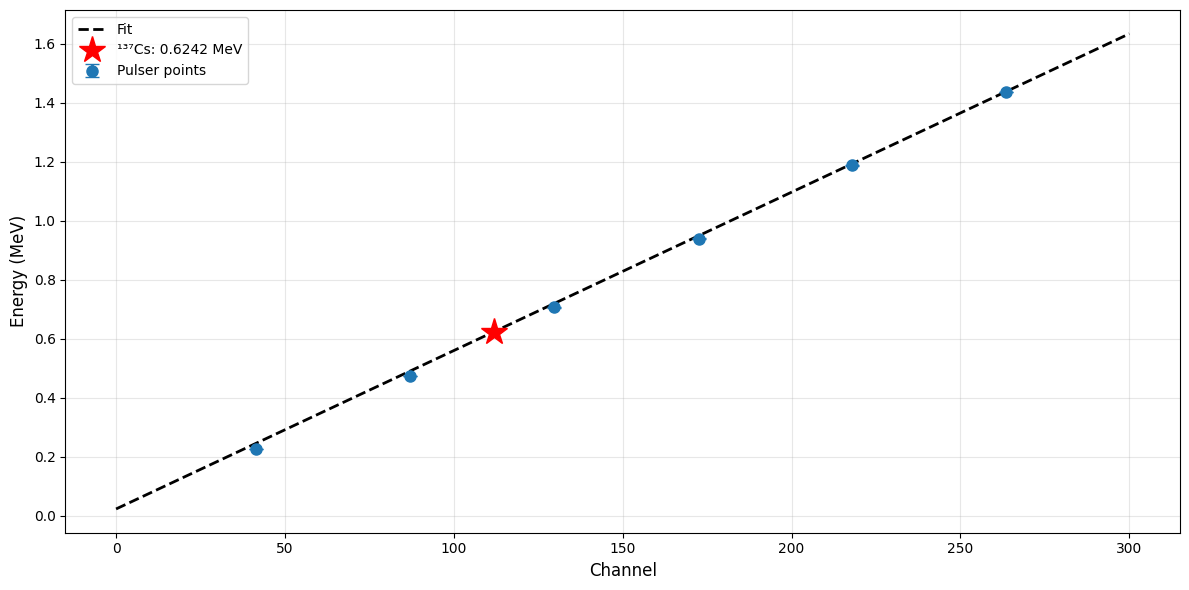

m = 0.005369 ± 0.000065 MeV/ch
b = 0.023525 ± 0.007253 MeV
χ²_red = 0.0005


In [113]:
channels_calib = np.concatenate([pulser_C, [cs_conv_mu]])
energies_calib = np.concatenate([pulser_energies_calib, [cs_conv_ene]])
energies_calib_sigma = np.concatenate([pulser_C_sigma * m, [0.000001]])

popt_calib, pcov_calib = optimize.curve_fit(linear, channels_calib, energies_calib, sigma=energies_calib_sigma)
perr_calib = np.sqrt(np.diag(pcov_calib))

m_calib = popt_calib[0]
b_calib = popt_calib[1]
m_calib_sigma = perr_calib[0]
b_calib_sigma = perr_calib[1]

energies_fit = linear(channels_calib, *popt_calib)
chi2_calib = compute_chi2(energies_calib, energies_fit, dof=len(channels_calib) - 2)

channels_plot = np.linspace(0, 300, 200)
energy_plot = linear(channels_plot, *popt_calib)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_plot, energy_plot, 'k--', linewidth=2, label='Fit')
ax.errorbar(pulser_C, pulser_energies_calib, yerr=pulser_C_sigma * m, fmt='o', markersize=8, capsize=5, elinewidth=2, label='Pulser points')
ax.plot(cs_conv_mu, cs_conv_ene, 'r*', markersize=20, label=f'¹³⁷Cs: {cs_conv_ene:.4f} MeV')
ax.set_xlabel('Channel', fontsize=12)
ax.set_ylabel('Energy (MeV)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"m = {m_calib:.6f} ± {m_calib_sigma:.6f} MeV/ch")
print(f"b = {b_calib:.6f} ± {b_calib_sigma:.6f} MeV")
print(f"χ²_red = {chi2_calib:.4f}")